# Four estimators, side by side

The package implements four methods for the same question. This notebook runs
them on the same problems and, more usefully, shows where each one stops.

| Method | Proposal | How the intermediate level is set |
| --- | --- | --- |
| **Safe-ICE** | vMF-Nakagami mixture plus a heavy-tailed component | smoothed indicator $\Phi(-g/\sigma)$ |
| **ICE-vMFNM** | vMF-Nakagami mixture | smoothed indicator $\Phi(-g/\sigma)$ |
| **CE-GM** | Gaussian mixture | hard threshold at the $\rho$-quantile |
| **Subset simulation** | none — MCMC in nested levels | hard threshold at the $p_0$-quantile |

The first three are importance sampling: fit a proposal, reweight by $p/q$.
The fourth is not, which is what makes it useful as a check rather than a
second opinion from the same machinery.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from safe_ice import (
    CrossEntropyGaussianMixture,
    ICEvMFNM,
    SafeICE,
    SubsetSimulation,
)
from safe_ice.problems.benchmarks import BenchmarkProblems

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})

METHODS = {
    "Safe-ICE": (SafeICE, {"N": 1000, "max_iterations": 15}),
    "ICE-vMFNM": (ICEvMFNM, {"K": 4, "N": 1000, "max_iterations": 15}),
    "CE-GM": (CrossEntropyGaussianMixture, {"K": 4, "N": 2000}),
    "subset sim": (SubsetSimulation, {"N": 2000}),
}
COLOURS = {
    "Safe-ICE": "#1d3557",
    "ICE-vMFNM": "#457b9d",
    "CE-GM": "#c1121f",
    "subset sim": "#2a9d8f",
}
SEEDS = range(5)


def run_all(limit_state, dimension, seeds=SEEDS):
    """Every method on one problem, returning estimates and evaluation counts."""
    out = {}
    for name, (cls, kwargs) in METHODS.items():
        estimates, costs = [], []
        for seed in seeds:
            instance = cls(
                limit_state_function=limit_state,
                dimension=dimension,
                random_state=seed,
                **kwargs,
            )
            pf, diagnostics = instance.run(verbose=False)
            estimates.append(pf)
            costs.append(
                diagnostics.get("n_evaluations")
                or instance.N * (len(diagnostics["iterations"]) + 1)
            )
        out[name] = (np.array(estimates), int(np.median(costs)))
    return out

## Where they agree

Two problems with answers known in closed form, so there is nothing to argue
about.

In [2]:
def sphere(beta):
    return lambda u: beta - np.linalg.norm(u, axis=-1)


problems = [
    (
        "two-mode, z=3",
        BenchmarkProblems.two_mode_opposite_directions(z=3.0),
        2,
        float(2 * stats.norm.cdf(-3.0)),
        "closed form",
    ),
    (
        "sphere, d=2",
        sphere(3.5),
        2,
        float(stats.chi2.sf(3.5**2, df=2)),
        "closed form",
    ),
]

for label, limit_state, dimension, reference, source in problems:
    print(f"{label}  ({source}, P_F = {reference:.4e})")
    for name, (estimates, cost) in run_all(limit_state, dimension).items():
        median = float(np.median(estimates))
        print(
            f"    {name:12s} {median:.4e}  {median / reference:5.2f}x  "
            f"{cost:7,d} evaluations"
        )
    print()

two-mode, z=3  (closed form, P_F = 2.6998e-03)


    Safe-ICE     2.7606e-03   1.02x    3,000 evaluations
    ICE-vMFNM    2.6172e-03   0.97x    4,000 evaluations
    CE-GM        2.5137e-03   0.93x    8,000 evaluations
    subset sim   2.8600e-03   1.06x    6,000 evaluations

sphere, d=2  (closed form, P_F = 2.1875e-03)


    Safe-ICE     2.2277e-03   1.02x    3,000 evaluations
    ICE-vMFNM    2.1803e-03   1.00x    4,000 evaluations
    CE-GM        1.7241e-03   0.79x    6,000 evaluations
    subset sim   2.5950e-03   1.19x    6,000 evaluations



All four land on the answer. On a two-dimensional, gently-shaped problem the
choice of method barely matters — which is worth knowing, because it means the
differences below are not about one implementation being better written than
another.

## Where multiple modes separate them

The four-mode series system puts its failure region in four disconnected
lobes. A proposal that finds three of them returns three quarters of the
answer, and looks perfectly converged while doing so.

In [3]:
FOUR_MODE = BenchmarkProblems.four_mode_series_system(z=1.0)
FOUR_MODE_PF = 6.465e-05  # crude MC over 2e7 samples

four_mode_results = run_all(FOUR_MODE, 2, seeds=range(6))

print(f"four-mode series system, reference {FOUR_MODE_PF:.4e}")
print(f"    {'method':12s} {'median':>11s} {'ratio':>7s} {'worst seed':>11s}")
print("    " + "-" * 45)
for name, (estimates, _cost) in four_mode_results.items():
    ratios = estimates / FOUR_MODE_PF
    worst = ratios[np.argmax(np.abs(np.log(np.maximum(ratios, 1e-300))))]
    print(
        f"    {name:12s} {np.median(estimates):11.4e} "
        f"{np.median(ratios):6.2f}x {worst:10.2f}x"
    )

four-mode series system, reference 6.4650e-05
    method            median   ratio  worst seed
    ---------------------------------------------
    Safe-ICE      5.9278e-05   0.92x       0.79x
    ICE-vMFNM     3.9135e-05   0.61x       0.13x
    CE-GM         3.1847e-05   0.49x       0.17x
    subset sim    6.2050e-05   0.96x       0.58x


In [4]:
def lobes_covered(samples, g_values):
    """How many of the four lobes the failing samples fall in."""
    failing = np.asarray(samples)[np.asarray(g_values) <= 0]
    if failing.size == 0:
        return 0
    keys = list(
        zip(
            np.sign(failing[:, 0] + failing[:, 1]).astype(int),
            np.sign(failing[:, 0] - failing[:, 1]).astype(int),
            strict=False,
        )
    )
    counts = {}
    for key in keys:
        counts[key] = counts.get(key, 0) + 1
    return sum(1 for count in counts.values() if count >= 3)


print("lobes of the failure region the final samples reach (4 exist):")
for name, (cls, kwargs) in METHODS.items():
    found = []
    for seed in range(6):
        _pf, diagnostics = cls(
            limit_state_function=FOUR_MODE, dimension=2, random_state=seed, **kwargs
        ).run(verbose=False)
        found.append(
            lobes_covered(diagnostics["final_samples"], diagnostics["final_g_values"])
        )
    print(f"    {name:12s} {found}   median {int(np.median(found))}/4")

lobes of the failure region the final samples reach (4 exist):


    Safe-ICE     [4, 4, 4, 4, 4, 4]   median 4/4


    ICE-vMFNM    [4, 4, 1, 4, 4, 4]   median 4/4


    CE-GM        [3, 3, 4, 3, 4, 2]   median 3/4
    subset sim   [4, 4, 4, 4, 4, 4]   median 4/4


The lobe count explains the estimates above, and the three methods miss modes
for different reasons.

CE-GM is consistently short, at three of four, because it fits a mixture to
the best tenth of each iteration and that concentrates wherever the first
elites happened to land. ICE-vMFNM usually finds all four, but one seed in six
collapsed to a single lobe — it has no penalty holding its components apart,
so nothing stops EM from merging them, and that one run is where its worst-case
0.13x comes from. Safe-ICE's penalised EM is precisely the mechanism that
prevents it.

Subset simulation reaches all four for a different reason again: its chains do
not fit anything, they walk, so there is no fitted object to collapse.

## Where dimension separates them

The prior's mass concentrates on a shell of radius $\sqrt{d}$. Representing
that with a Gaussian mixture is fine at $d = 10$ and hopeless by $d = 50$; a
vMF-Nakagami mixture is written in polar form, separating radius from
direction, and so does not have to represent a shell with an ellipsoid.

In [5]:
dimension_cases = [(2, 3.5), (10, 5.0), (50, 9.0), (100, 12.0)]
by_dimension = {name: [] for name in METHODS}

for d, beta in dimension_cases:
    exact = float(stats.chi2.sf(beta**2, df=d))
    for name, (estimates, _cost) in run_all(sphere(beta), d, seeds=range(3)).items():
        by_dimension[name].append(float(np.median(estimates)) / exact)

print(f"{'method':12s}" + "".join(f"{f'd={d}':>10s}" for d, _ in dimension_cases))
print("-" * 52)
for name, ratios in by_dimension.items():
    print(f"{name:12s}" + "".join(f"{r:9.2f}x" for r in ratios))

method             d=2      d=10      d=50     d=100
----------------------------------------------------
Safe-ICE         1.01x     0.98x     0.97x     0.96x
ICE-vMFNM        1.00x     0.92x     1.04x     0.90x
CE-GM            0.90x     1.03x     0.00x     0.00x
subset sim       1.11x     0.95x     0.94x     1.03x


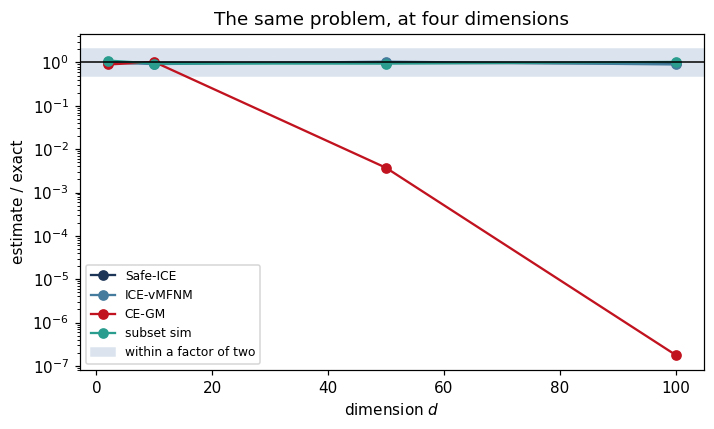

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
dims = [d for d, _ in dimension_cases]
for name, ratios in by_dimension.items():
    ax.plot(dims, ratios, "o-", color=COLOURS[name], label=name, ms=6)
ax.axhline(1.0, color="black", lw=1.0)
ax.axhspan(0.5, 2.0, color="#dbe4ee", zorder=0, label="within a factor of two")
ax.set(
    xlabel="dimension $d$",
    ylabel="estimate / exact",
    yscale="log",
    title="The same problem, at four dimensions",
)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

The Gaussian mixture is seven orders of magnitude low at $d = 100$. That is
the claim the Safe-ICE paper makes about cross-entropy — "in high dimensions,
its Gaussian proposals collapse onto a thin shell" — and it is not a marginal
effect.

## What each of them costs

Accuracy is only half of it. The methods differ by an order of magnitude in
how many limit-state evaluations they need, which is the entire question when
one evaluation is a finite-element solve.

In [7]:
FITS_A_PROPOSAL = {"Safe-ICE", "ICE-vMFNM", "CE-GM"}

print(f"{'method':12s} {'evaluations':>13s} {'informing the fit':>19s}")
print("-" * 48)
for name, (cls, kwargs) in METHODS.items():
    _pf, diagnostics = cls(
        limit_state_function=FOUR_MODE, dimension=2, random_state=0, **kwargs
    ).run(verbose=False)
    total = diagnostics.get("n_evaluations") or kwargs["N"] * (
        len(diagnostics["iterations"]) + 1
    )
    if name in FITS_A_PROPOSAL:
        discarded = diagnostics.get("samples_discarded", 0.0)
        share = f"{(total - discarded) / total:.0%}"
    else:
        # Subset simulation has no proposal to fit, so the column is meaningless
        # rather than perfect.
        share = "n/a"
    print(f"{name:12s} {total:13,d} {share:>18s}")

method         evaluations   informing the fit
------------------------------------------------


Safe-ICE             3,000               100%


ICE-vMFNM            5,000               100%
CE-GM               14,000                26%
subset sim          10,000                n/a


Cross-entropy keeps only the best tenth of each iteration, which is the
"diminishing statistical efficiency" the paper points at. The smoothed
indicator that ICE and Safe-ICE use is precisely the fix: every sample
contributes something, weighted by how close it came.

## Where each one stops

Being fair about this matters more than the tables above, because a method's
limits are what decide whether it suits a given problem.

**Safe-ICE.** Its smoothing is $\Phi(-g/\sigma)$, so it assumes $g$ is on a
scale comparable to $\sigma_0$. That is now chosen automatically, but the
sensitivity is real: a limit state in physical units with a spread of 33 and a
fixed $\sigma_0 = 1$ returns a third of the answer, quietly. It also needs a
limit state with a usable gradient — a connectivity problem returning $\pm 1$
gives the smoothing nothing to work with.

**ICE-vMFNM.** Accurate on average, but the number of components is a choice
made in advance and the answer depends on it: on the four-mode problem the
relative error of the mean runs 0.084 at $K=2$, 0.276 at $K=4$ and 0.290 at
$K=8$ — adding components makes it worse, and nothing tells you which to use.
With no penalty holding components apart it can also collapse onto one mode,
which happened on one seed in six above and cost a factor of eight.

**CE-GM.** Fine in low dimension with few modes; unusable by $d=50$, and
loses modes on multi-modal problems regardless of $K$.

**Subset simulation.** No proposal family to misfit, so nothing collapses —
but it needs far more evaluations for the same precision, and its estimate
carries a small bias at finite $N$ because the thresholds are estimated from
the same samples as the conditional probabilities. On the sphere at $d=2$ its
mean over twelve runs moves 0.90x, 1.01x, 1.02x of the exact value as $N$ goes
1000, 4000, 16000, with the coefficient of variation falling from 18.9% to
6.9%.

The practical reading: use Safe-ICE for the estimate, and subset simulation to
check it. They share no machinery, so when they agree it is evidence about the
answer rather than about the code — which is how two defects in this
repository were found.